# VOYAGE AI - Traveller Segmentation Business Analysis

This notebook loads clustering results, compares algorithms, profiles clusters, assigns business segment names, generates recommendations, creates visualizations, and outputs a text report. All results and plots will be displayed directly below each code cell.

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

print('VOYAGE AI - TRAVELLER SEGMENTATION BUSINESS ANALYSIS')

VOYAGE AI - TRAVELLER SEGMENTATION BUSINESS ANALYSIS


In [2]:
# 2. Load Business Data (Clustering Results)
kmeans_df       = pd.read_csv('kmeans_results.csv')
dbscan_df       = pd.read_csv('dbscan_results.csv')
hierarchical_df = pd.read_csv('hierarchical_results.csv')
gmm_df          = pd.read_csv('gmm_results.csv')

feature_cols = ['trip_frequency', 'average_booking_value',
                'destination_diversity', 'session_duration', 'search_behavior']

In [3]:
# ─────────────────────────────────────────────
# PERSONA MAPPING
# ─────────────────────────────────────────────
persona_map = {
    0: 'Frequent Travellers',
    1: 'Occasional Travellers',
    2: 'Least Travellers',
    3: 'High Spenders',
    4: 'Budget Travellers'
}

def map_persona(labels):
    unique_labels = sorted(pd.Series(labels).unique())
    mapping = {label: persona_map.get(i, f'Persona {i+1}') for i, label in enumerate(unique_labels)}
    return pd.Series(labels).map(mapping)

for df in [kmeans_df, dbscan_df, hierarchical_df, gmm_df]:
    if 'Cluster' in df.columns:
        df['Persona'] = map_persona(df['Cluster'])


In [4]:
# ─────────────────────────────────────────────
# EXTRACT SCORES FROM CSVs
# ─────────────────────────────────────────────
# Adjust column names below if yours differ
def get_scores(df, name):
    sil = df['Silhouette Score'].iloc[0] if 'Silhouette Score' in df.columns else np.nan
    db  = df['Davies-Bouldin Score'].iloc[0] if 'Davies-Bouldin Score' in df.columns else np.nan
    n_clusters = df['Cluster'].nunique() if 'Cluster' in df.columns else np.nan
    return {'Algorithm': name, 'Silhouette Score': sil, 'Davies-Bouldin Score': db, 'N Clusters': n_clusters}

scores_df = pd.DataFrame([
    get_scores(kmeans_df,       'KMeans'),
    get_scores(hierarchical_df, 'Hierarchical'),
    get_scores(dbscan_df,       'DBSCAN'),
    get_scores(gmm_df,          'GMM'),
])

print(scores_df.to_string(index=False))

   Algorithm  Silhouette Score  Davies-Bouldin Score  N Clusters
      KMeans               NaN                   NaN           4
Hierarchical               NaN                   NaN           3
      DBSCAN               NaN                   NaN          38
         GMM               NaN                   NaN           8


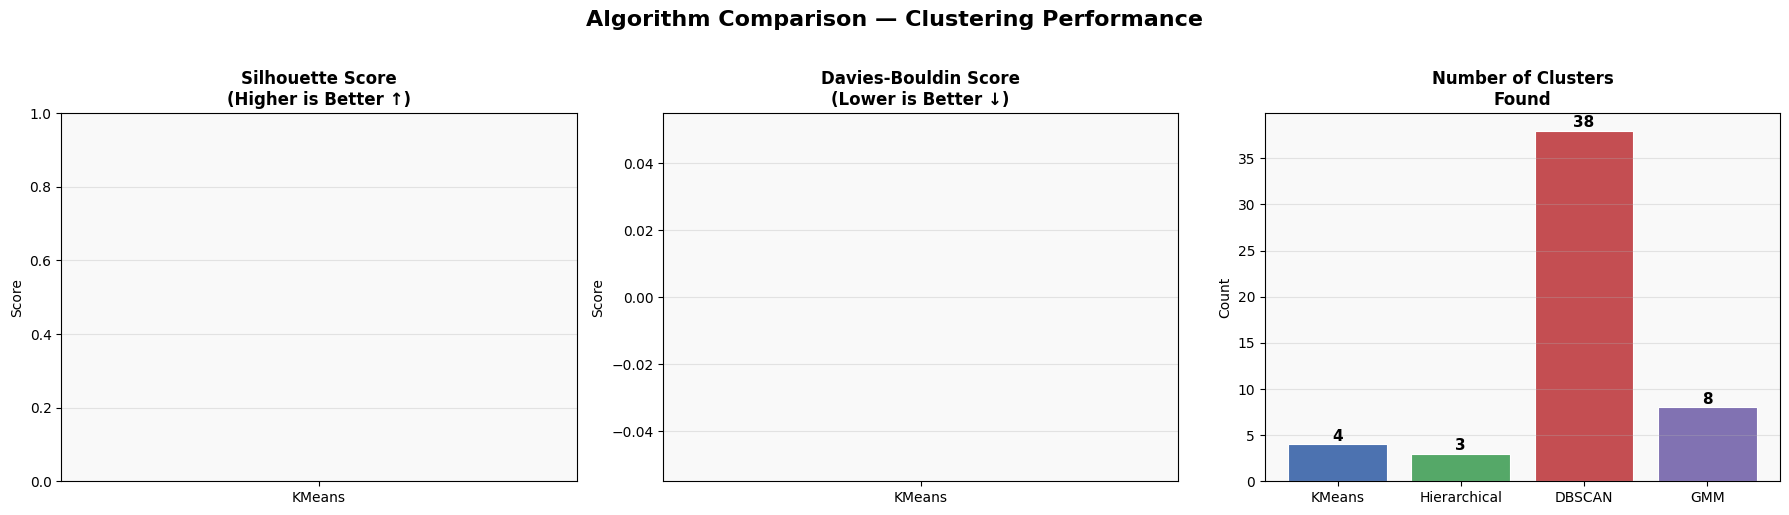

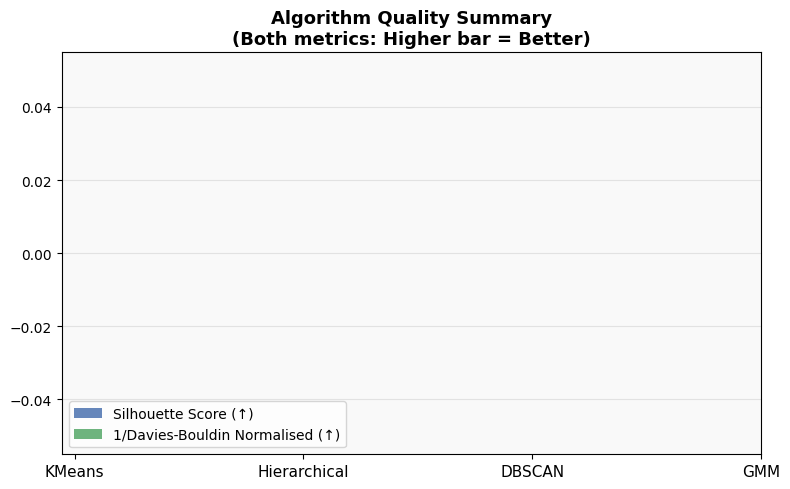

In [5]:
# ═══════════════════════════════════════════════════════════════
# PART 1 — ALGORITHM COMPARISON GRAPHS
# ═══════════════════════════════════════════════════════════════

algo_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Algorithm Comparison — Clustering Performance', fontsize=16, fontweight='bold', y=1.02)

# — Silhouette Score (higher = better)
ax = axes[0]
bars = ax.bar(scores_df['Algorithm'], scores_df['Silhouette Score'], color=algo_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Silhouette Score\n(Higher is Better ↑)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, max(scores_df['Silhouette Score'].dropna()) * 1.3 if not scores_df['Silhouette Score'].dropna().empty else 1)
for bar, val in zip(bars, scores_df['Silhouette Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')

# — Davies-Bouldin Score (lower = better)
ax = axes[1]
bars = ax.bar(scores_df['Algorithm'], scores_df['Davies-Bouldin Score'], color=algo_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Davies-Bouldin Score\n(Lower is Better ↓)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score')
for bar, val in zip(bars, scores_df['Davies-Bouldin Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')

# — Number of Clusters
ax = axes[2]
bars = ax.bar(scores_df['Algorithm'], scores_df['N Clusters'], color=algo_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Number of Clusters\nFound', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, scores_df['N Clusters']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{int(val)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('algo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# — Radar / Spider Chart: All metrics together
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(scores_df))
width = 0.35

# Normalize scores for side-by-side view
sil_norm = scores_df['Silhouette Score']
db_norm  = 1 / (scores_df['Davies-Bouldin Score'] + 1e-9)  # invert so higher = better

ax.bar(x - width/2, sil_norm,  width, label='Silhouette Score (↑)', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, db_norm / db_norm.max(), width, label='1/Davies-Bouldin Normalised (↑)', color='#55A868', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(scores_df['Algorithm'], fontsize=11)
ax.set_title('Algorithm Quality Summary\n(Both metrics: Higher bar = Better)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.savefig('algo_quality_summary.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='trip_frequency', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='average_booking_value', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='session_duration', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:73: Fu

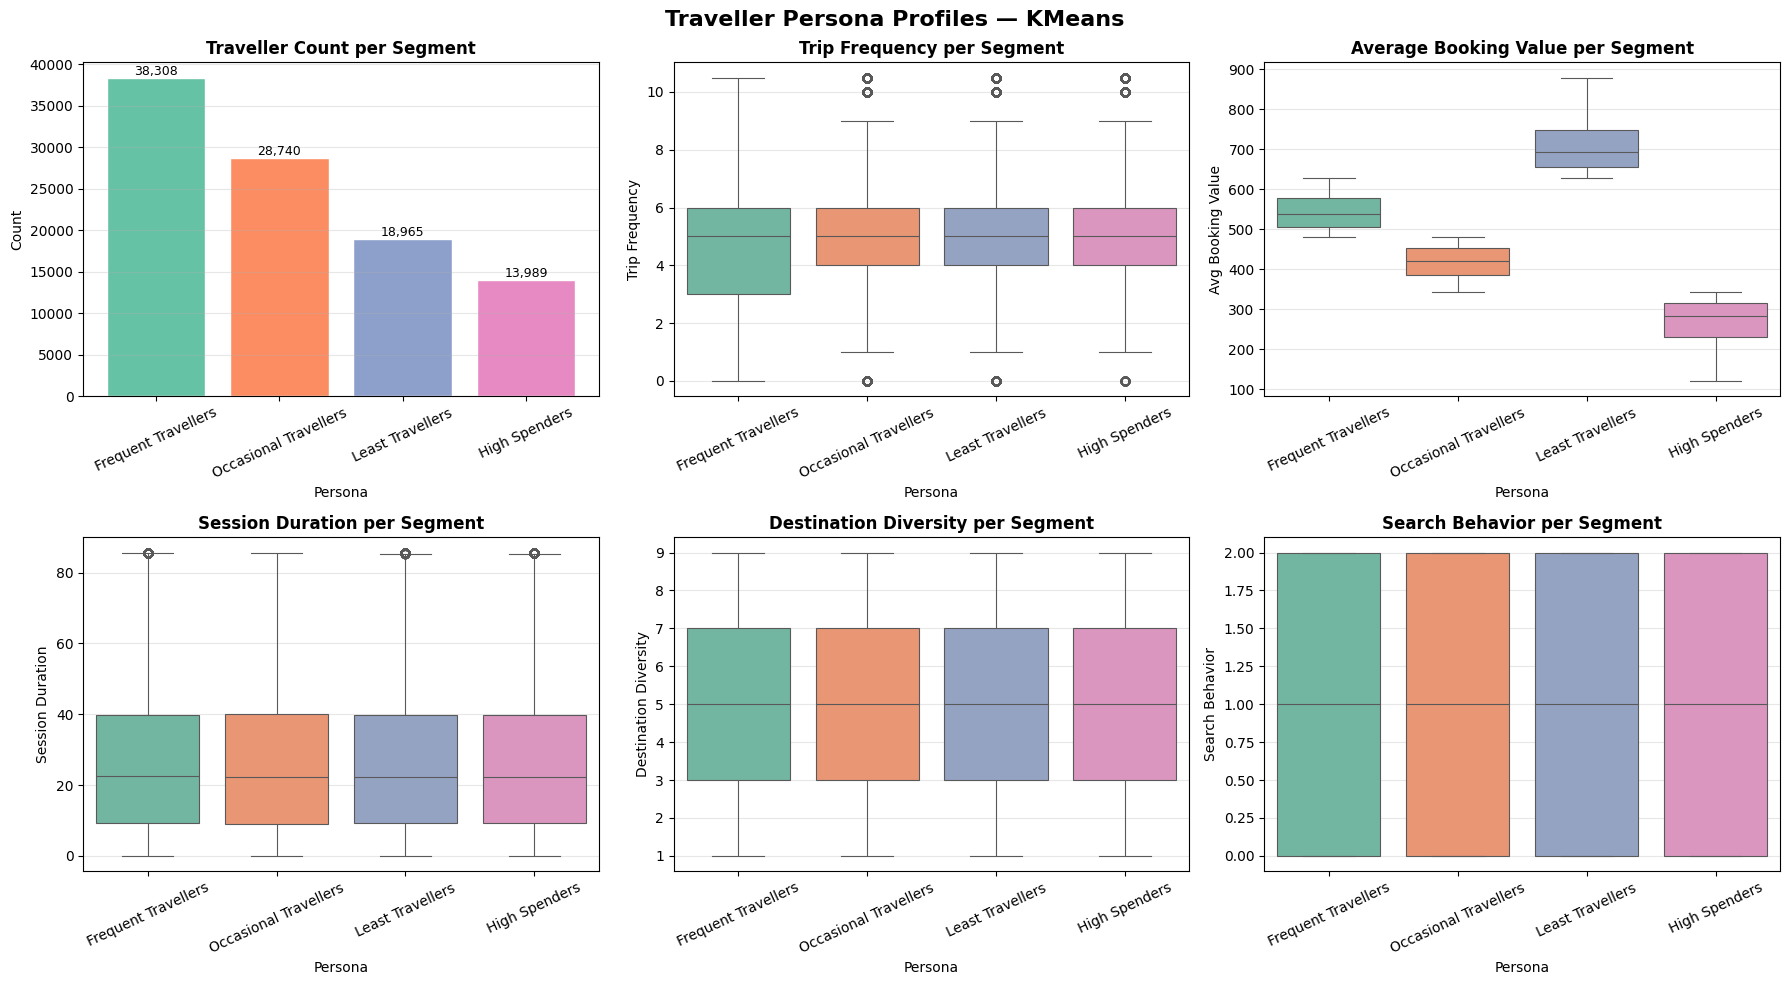

✅ KMeans persona graphs done.


C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='trip_frequency', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='average_booking_value', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='session_duration', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:73: Fu

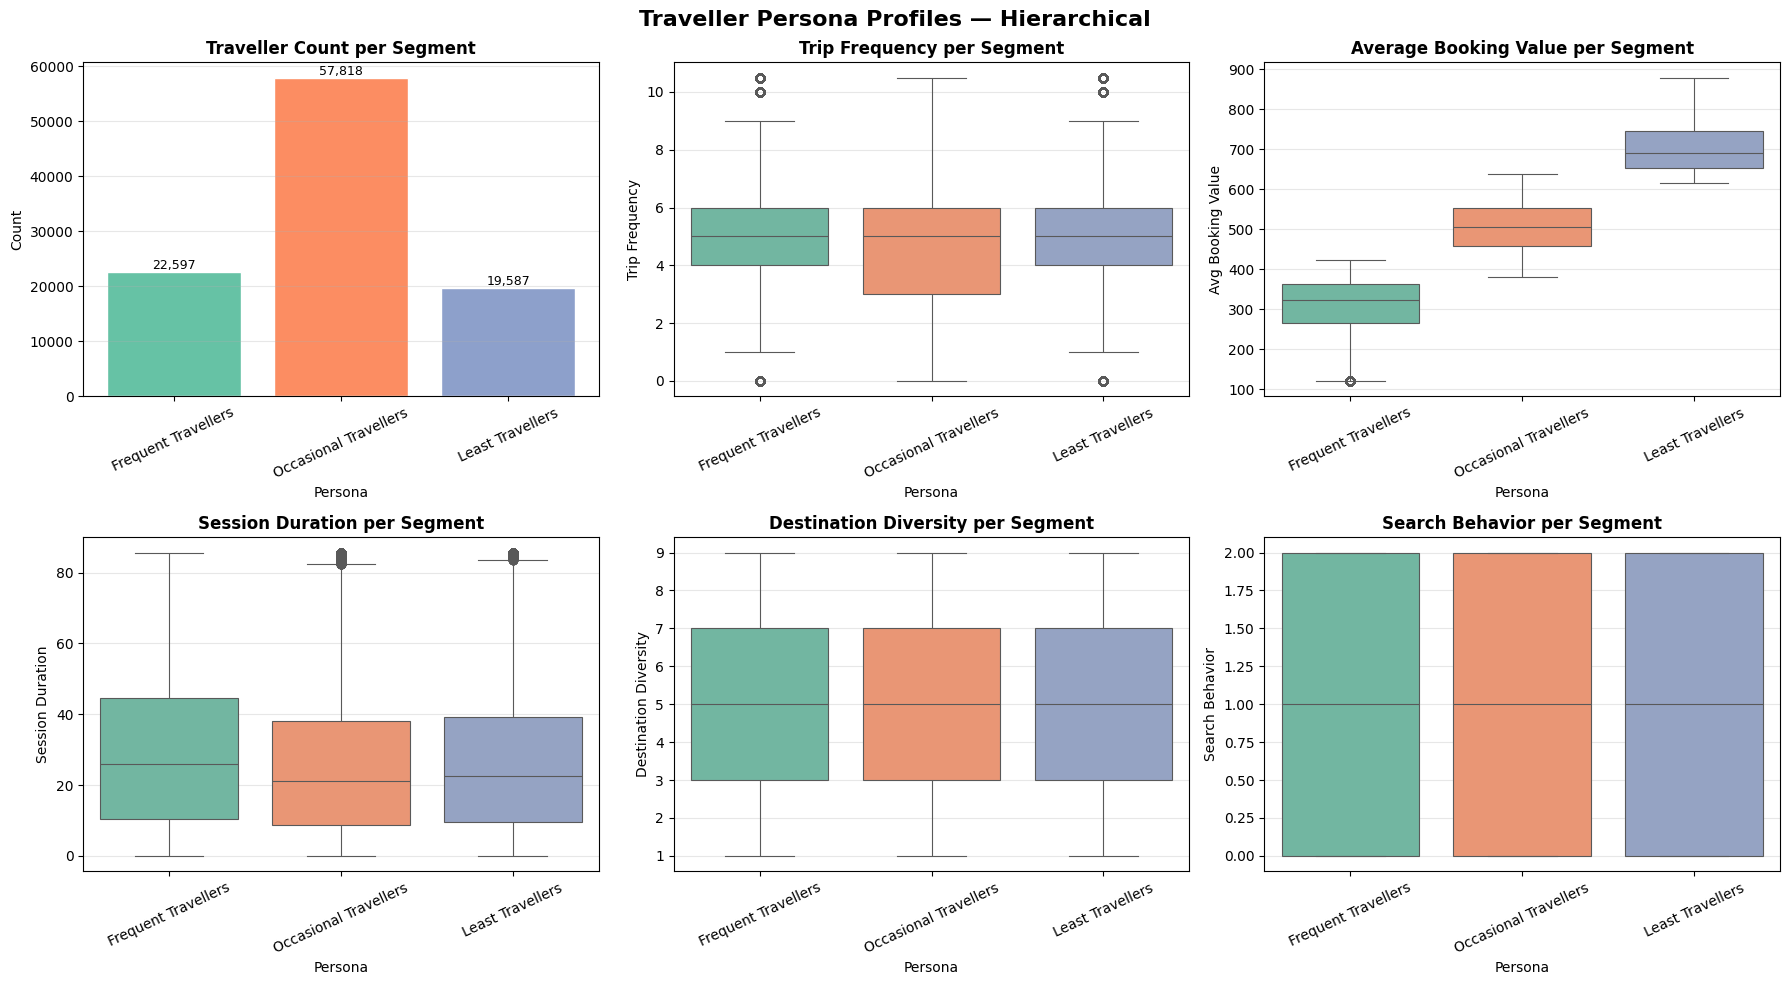

✅ Hierarchical persona graphs done.


C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='trip_frequency', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='average_booking_value', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='session_duration', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:73: Fu

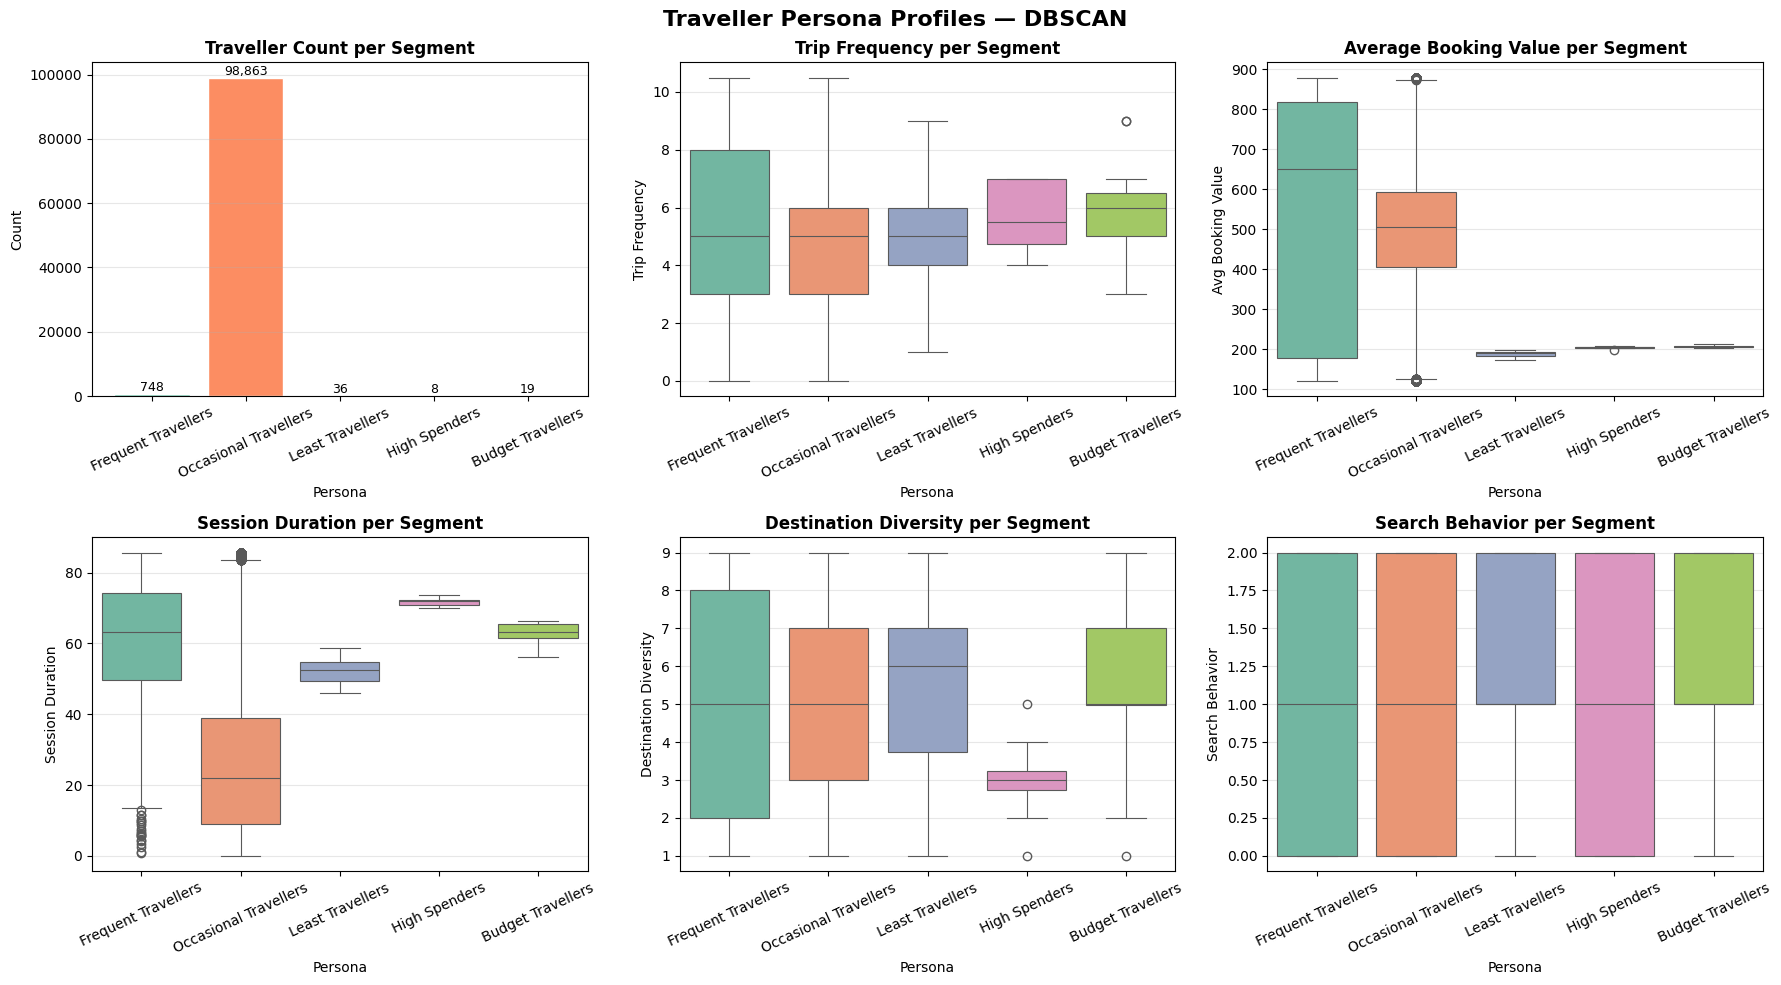

✅ DBSCAN persona graphs done.


C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='trip_frequency', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='average_booking_value', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='session_duration', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_19496\3734730792.py:73: Fu

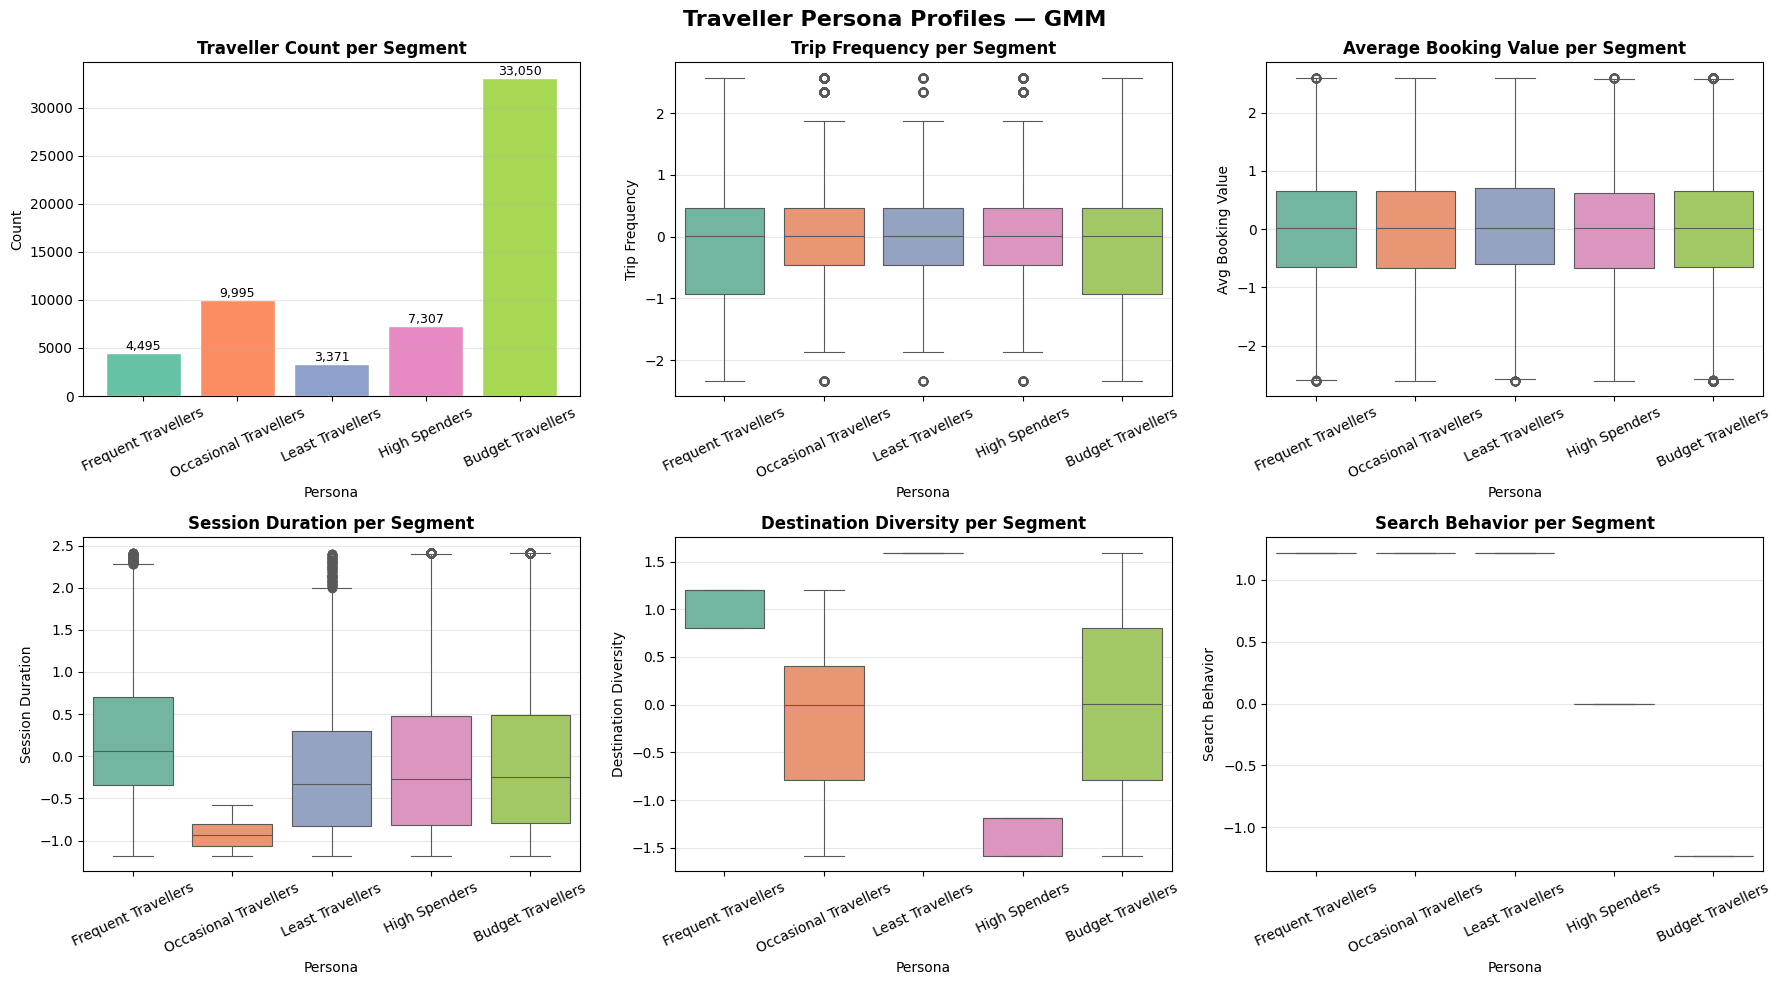

✅ GMM persona graphs done.


In [6]:

# ═══════════════════════════════════════════════════════════════
# PART 2 — PERSONA / TRAVELLER SEGMENT GRAPHS
# ═══════════════════════════════════════════════════════════════

persona_order  = ['Frequent Travellers', 'Occasional Travellers',
                  'Least Travellers', 'High Spenders', 'Budget Travellers']
persona_colors = sns.color_palette('Set2', 5)

datasets = {
    'KMeans':       kmeans_df,
    'Hierarchical': hierarchical_df,
    'DBSCAN':       dbscan_df,
    'GMM':          gmm_df,
}

def plot_persona_graphs(df, method_name):
    if 'Persona' not in df.columns:
        print(f"No Persona column in {method_name}, skipping.")
        return

    present_personas = [p for p in persona_order if p in df['Persona'].values]
    palette = {p: persona_colors[i] for i, p in enumerate(persona_order) if p in present_personas}

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Traveller Persona Profiles — {method_name}', fontsize=16, fontweight='bold')

    # 1. Traveller Count per Segment
    ax = axes[0, 0]
    counts = df['Persona'].value_counts().reindex(present_personas).dropna()
    bars = ax.bar(counts.index, counts.values,
                  color=[palette[p] for p in counts.index], edgecolor='white')
    ax.set_title('Traveller Count per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{int(val):,}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 2. Trip Frequency per Segment
    ax = axes[0, 1]
    sns.boxplot(x='Persona', y='trip_frequency', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Trip Frequency per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Trip Frequency')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 3. Average Booking Value per Segment
    ax = axes[0, 2]
    sns.boxplot(x='Persona', y='average_booking_value', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Average Booking Value per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Avg Booking Value')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 4. Session Duration per Segment
    ax = axes[1, 0]
    sns.boxplot(x='Persona', y='session_duration', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Session Duration per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Session Duration')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 5. Destination Diversity per Segment
    ax = axes[1, 1]
    sns.boxplot(x='Persona', y='destination_diversity', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Destination Diversity per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Destination Diversity')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 6. Search Behavior per Segment
    ax = axes[1, 2]
    sns.boxplot(x='Persona', y='search_behavior', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Search Behavior per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Search Behavior')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'persona_graphs_{method_name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ {method_name} persona graphs done.")


# Run for all 4 algorithms
for method, df in datasets.items():
    plot_persona_graphs(df, method)

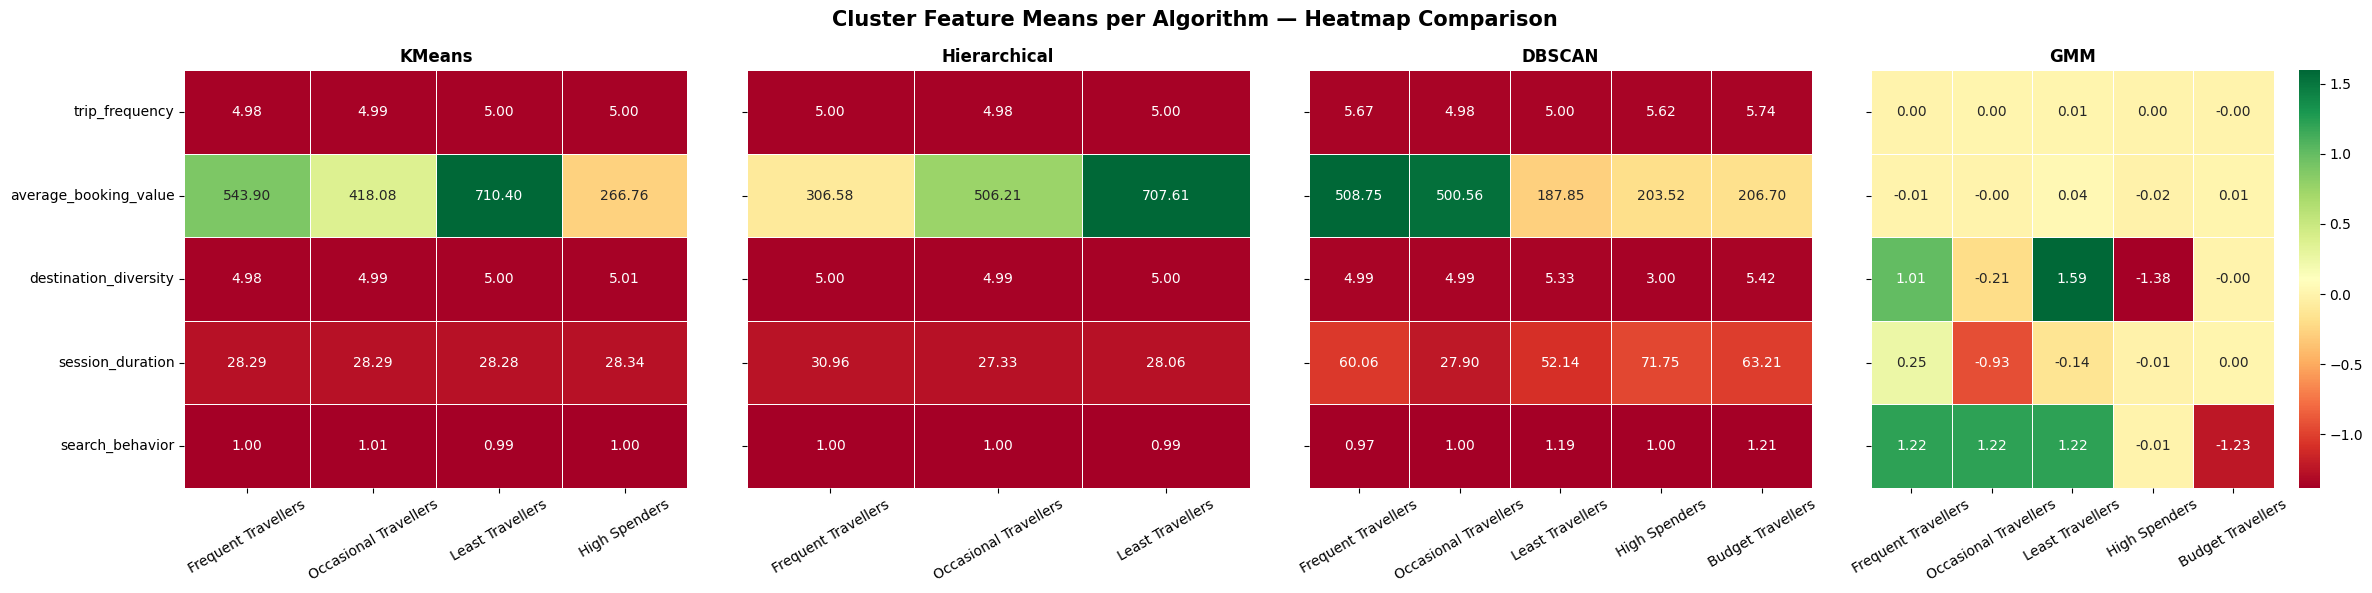

✅ All done!


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)
fig.suptitle('Cluster Feature Means per Algorithm — Heatmap Comparison', fontsize=15, fontweight='bold')

for ax, (method, df) in zip(axes, datasets.items()):
    if 'Persona' not in df.columns:
        continue
    means = df.groupby('Persona')[feature_cols].mean()
    means = means.reindex([p for p in persona_order if p in means.index])
    sns.heatmap(means.T, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
                linewidths=0.5, cbar=(method == 'GMM'))
    ax.set_title(method, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('cross_algo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All done!")